# Система прогнозирования продаж для «Прилавка»

## Описание задачи

Ваш клиент — компания «Прилавок», новая сеть дарксторов в России, специализирующаяся на быстрой доставке продуктов и товаров повседневного спроса. Компания работает с 2023 года и управляет более чем 45 дарксторами.

**Бизнес-проблема**

Эффективность дарксторов критически зависит от точности управления запасами. Текущая система планирования закупок работает на субъективных оценках аналитиков, что приводит к разным проблемам:
- К дефициту товаров в пиковые периоды (недополучение 3–5% выручки).
- К избыточным запасам и списаниям продуктов с коротким сроком годности (2–3% от выручки).
- К неэффективному использованию времени аналитиков (15–20 часов в неделю на ручное планирование).

**Цель проекта**

Разработать автоматизированную систему прогнозирования недельных продаж для каждого отдела во всех дарксторах с использованием машинного обучения (модель CatBoost). Система будет работать в режиме пакетного внедрения с недельным циклом: модель будет переобучаться каждое воскресенье вечером, а к понедельнику утром прогнозы будут готовы для передачи в систему планирования закупок.

## Описание данных

Для работы доступны исторические данные о продажах за февраль 2023 — октябрь 2025, организованные в виде нескольких таблиц в PostgreSQL:

1. Таблица `sales` — исторические данные о продажах:
   - `Store` — номер даркстора (1–45).
   - `Dept` — номер отдела внутри даркстора (1–99).
   - `Date` — неделя (дата начала недели).
   - `Weekly_Sales` — недельные продажи (руб., целевая переменная).
   - `IsHoliday` — признак праздничной недели.

2. Таблица `stores` — информация о дарксторах:
   - `Store` — номер даркстора.
   - `Type` — тип даркстора (A, B, C).
   - `Size` — размер даркстора в условных единицах.

3. Таблица `features` — внешние факторы:
   - `Store`, `Date` — идентификаторы.
   - `Temperature` — средняя температура за неделю.
   - `Fuel_Price` — средняя цена бензина.
   - `MarkDown1-5` — факторы рекламных акций и скидок.
   - `CPI` — индекс потребительских цен.
   - `Unemployment` — уровень безработицы.

4. Таблица `plan` — данные для инференса (ноябрь 2025 — июль 2026), содержит те же столбцы, что и `sales`, кроме `Weekly_Sales`.

## План работы


1. Первичный анализ и очистка данных.
2. Предобработка и создание признаков.
3. Мониторинг стабильности признаков (PSI).
4. Обучение модели CatBoost и оценка качества.



In [1]:
!pip install boto3 -q
!pip install python-dotenv -q

In [2]:
# Здесь все необходимые импорты
import os
from sqlalchemy import create_engine


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import psycopg2

import warnings
warnings.filterwarnings("ignore")

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import io
import pickle
import boto3
import os
from dotenv import load_dotenv
load_dotenv("con.env")

True

Фиксируем `random_state` для воспроизводимости результатов.

In [3]:
RANDOM_STATE = 42

### Шаг 1. Первичный анализ данных

In [ ]:
connection_string = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}?sslmode=require"
)

engine = create_engine(connection_string)


In [5]:
sales = pd.read_sql_query("SELECT * FROM sales", con = engine)
stores = pd.read_sql_query("SELECT * FROM stores", con = engine)
features = pd.read_sql_query("SELECT * FROM features", con =  engine)


In [6]:
display(sales.head(3))
display(sales.sample(3, random_state=42))
display(sales.tail(3))

,store,dept,date,weekly_sales,is_holiday
0,1,1,2023-02-05,24924.50,False
1,29,5,2023-02-05,15552.08,False
2,29,6,2023-02-05,3200.22,False


,store,dept,date,weekly_sales,is_holiday
272342,13,29,2024-11-10,8479.04,False
176581,29,82,2024-03-31,7023.82,False
354212,10,96,2025-05-25,13532.62,False


,store,dept,date,weekly_sales,is_holiday
421567,19,31,2025-10-26,3128.17,False
421568,19,33,2025-10-26,5740.14,False
421569,45,98,2025-10-26,1076.80,False


In [7]:
display(stores.head(3))
display(stores.sample(3, random_state=42))
display(stores.tail(3))

,store,type,size
0,1,A,151315
1,2,A,202307
2,3,B,37392


,store,type,size
39,40,A,155083
25,26,A,152513
26,27,A,204184


,store,type,size
42,43,C,41062
43,44,C,39910
44,45,B,118221


In [8]:
display(features.head(3))
display(features.sample(3, random_state=42))
display(features.tail(3))


,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,42.31,2.572,7028.8,NaN,NaN,NaN,NaN,211.096358,8.106
1,29,5,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
2,29,6,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064


,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
272342,13,29,2024-11-10,33.80,3.513,67321.250637,30876.79,645.07,4407.38,7740.27,129.816710,6.392
176581,29,82,2024-03-31,36.04,3.638,7028.800000,NaN,NaN,NaN,NaN,134.068258,9.966
354212,10,96,2025-05-25,86.03,4.127,14506.570000,NaN,712.20,1701.28,3214.55,131.028774,7.382


,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
421567,19,31,2025-10-26,56.49,4.071,11970.746689,90.07,NaN,904.34,1665.77,138.728161,7.992
421568,19,33,2025-10-26,56.49,4.071,11970.746689,90.07,NaN,904.34,1665.77,138.728161,7.992
421569,45,98,2025-10-26,58.85,3.882,10459.117055,58.08,100.0,211.94,858.33,192.308899,8.667


In [9]:
sales.info()
stores.info()
features.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   weekly_sales  421570 non-null  float64
 4   is_holiday    421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   store   45 non-null     int64 
 1   type    45 non-null     object
 2   size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        ----

In [10]:
print("sales duplicates:", sales.duplicated().sum())
print("stores duplicates:", stores.duplicated().sum())
print("features duplicates:", features.duplicated().sum())

sales duplicates: 0
stores duplicates: 0
features duplicates: 0


In [11]:
sales = sales.drop_duplicates()
stores = stores.drop_duplicates()
features = features.drop_duplicates()

In [12]:

num_cols = features.select_dtypes(include=['float64', 'int64']).columns
cat_cols = features.select_dtypes(include=['object']).columns
for col in num_cols:
    features[col] = features[col].fillna(features[col].mean())
    
for col in cat_cols:
    features[col] = features[col].fillna(features[col].mode()[0])
print(features.isna().mean().sort_values(ascending=False))

store           0.0
dept            0.0
date            0.0
temperature     0.0
fuel_price      0.0
factor1         0.0
factor2         0.0
factor3         0.0
factor4         0.0
factor5         0.0
cpi             0.0
unemployment    0.0
dtype: float64


- Успешно выполнено подключение к PostgreSQL через переменные окружения без хранения credentials в коде.
- Загружены таблицы `sales`, `stores` и `features`.
- Таблица `sales` содержит 421 570 записей исторических продаж.
- Таблица `stores` содержит информацию о 45 магазинах.
- В таблице `features` обнаружены пропуски в признаках `factor2–factor5`, что связано с отсутствием маркетинговых активностей в отдельных периодах.
- Полных дубликатов в таблицах не обнаружено.
- Пропуски в числовых признаках заполнены средними значениями, категориальные — модой.
- После обработки пропуски полностью устранены.
- Данные готовы к дальнейшему анализу и feature engineering.

**Задача:** визуализируйте распределение продаж по времени (по месяцам и неделям).

Цель: выявить визуально наличие сезонности в данных. Обратите внимание:
- На периодические всплески (праздники, выходные).
- На общий тренд (рост и спад продаж).
- На аномальные периоды.

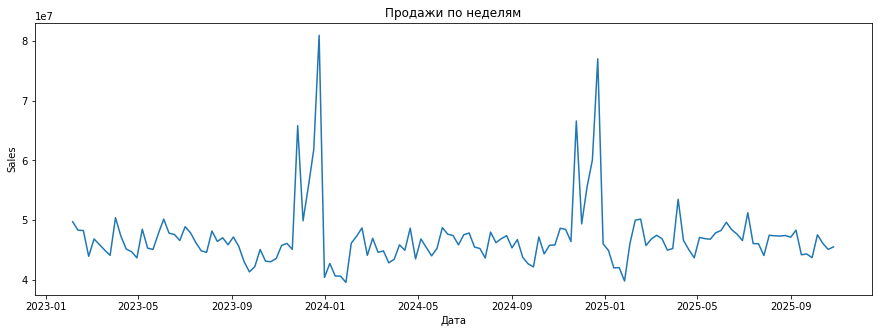

In [13]:
sales['date'] = pd.to_datetime(sales['date'])
weekly = sales.groupby('date')['weekly_sales'].sum().reset_index()


plt.figure(figsize=(15,5))
plt.plot(weekly['date'], weekly['weekly_sales'])
plt.title('Продажи по неделям')
plt.xlabel('Дата')
plt.ylabel('Sales')
plt.show()

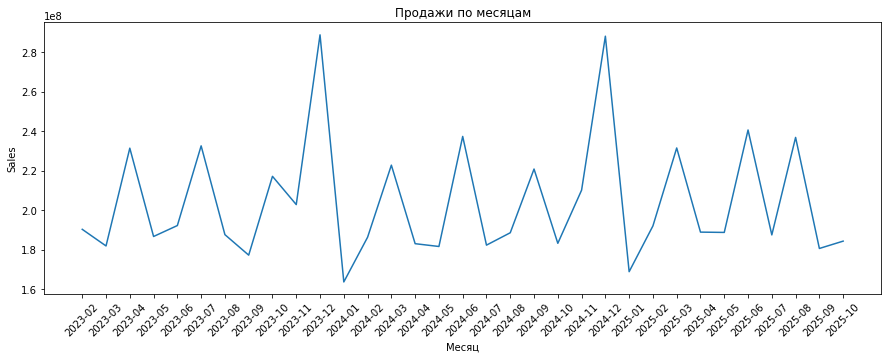

In [14]:
sales['month'] = sales['date'].dt.to_period('M')
monthly = sales.groupby('month')['weekly_sales'].sum().reset_index()
monthly['month'] = monthly['month'].astype(str)

plt.figure(figsize=(15,5))
plt.plot(monthly['month'], monthly['weekly_sales'])
plt.xticks(rotation=45)
plt.title('Продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Sales')
plt.show()

**Задача:** объедините три таблицы в одну для дальнейшего анализа.



In [15]:
sales['date'] = pd.to_datetime(sales['date'])
features['date'] = pd.to_datetime(features['date'])

df = sales.merge(stores, on='store', how='left') \
          .merge(features, on=['store', 'dept', 'date'], how='left')
print(df.shape)
print(df.head())
print(df.isna().sum().sort_values(ascending=False).head(10))

(421570, 17)
   store  dept       date  weekly_sales  is_holiday    month type    size  \
0      1     1 2023-02-05      24924.50       False  2023-02    A  151315   
1     29     5 2023-02-05      15552.08       False  2023-02    B   93638   
2     29     6 2023-02-05       3200.22       False  2023-02    B   93638   
3     29     7 2023-02-05      10820.05       False  2023-02    B   93638   
4     29     8 2023-02-05      20055.64       False  2023-02    B   93638   

   temperature  fuel_price  factor1      factor2      factor3      factor4  \
0        42.31       2.572   7028.8  3334.628621  1439.421384  3383.168256   
1        24.36       2.788   7028.8  3334.628621  1439.421384  3383.168256   
2        24.36       2.788   7028.8  3334.628621  1439.421384  3383.168256   
3        24.36       2.788   7028.8  3334.628621  1439.421384  3383.168256   
4        24.36       2.788   7028.8  3334.628621  1439.421384  3383.168256   

       factor5         cpi  unemployment  
0  4628.9750

**Задача:** оцените корреляцию целевой переменной `Weekly_Sales` с другими признаками.



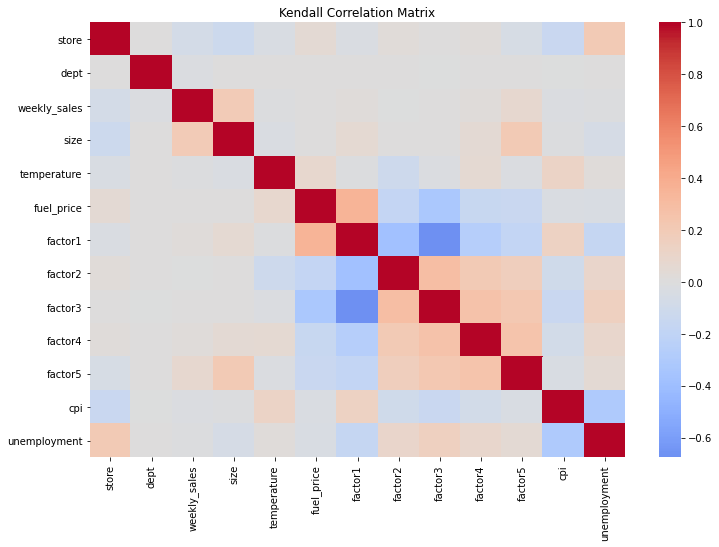

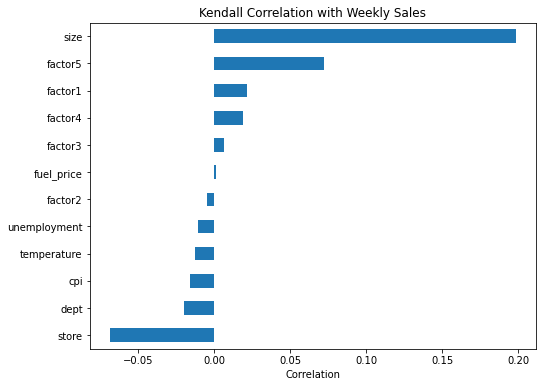

In [16]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr(method='kendall')

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Kendall Correlation Matrix")
plt.show()

corr_with_target = corr_matrix['weekly_sales'].sort_values()

plt.figure(figsize=(8, 6))
corr_with_target.drop('weekly_sales').plot(kind='barh')
plt.title("Kendall Correlation with Weekly Sales")
plt.xlabel("Correlation")
plt.show()

**Задача:** обработайте аномалии в продажах.



In [17]:
df[df['weekly_sales'] < 0].shape
df[df['weekly_sales'] < 0].head()

df['weekly_sales'] = df['weekly_sales'].clip(lower=0)
df['weekly_sales'].describe()

count    421570.000000
mean      15981.467250
std       22711.032446
min           0.000000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: weekly_sales, dtype: float64

**Задача:** исследовать аномально высокие продажи.



In [18]:
threshold = df['weekly_sales'].quantile(0.9999)
high_sales = df[df['weekly_sales'] >= threshold]

threshold, high_sales.shape

(283659.72232535254, (43, 17))

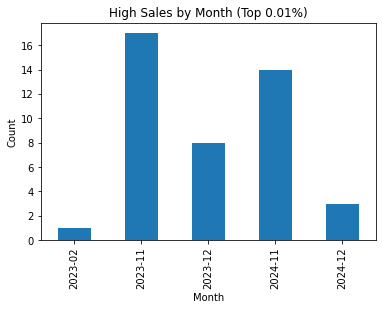

In [19]:
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['week'] = df['date'].dt.isocalendar().week
import matplotlib.pyplot as plt

high_sales['month'].value_counts().sort_index().plot(kind='bar')
plt.title("High Sales by Month (Top 0.01%)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

In [20]:
high_sales['is_holiday'].value_counts(normalize=True)
df['is_holiday'].value_counts(normalize=True)

False    0.929642
True     0.070358
Name: is_holiday, dtype: float64

In [21]:
high_sales['dept'].value_counts().head(10)

72    36
7      6
92     1
Name: dept, dtype: int64

**Распределение продаж во времени**

Продажи имеют выраженную сезонность и временную неравномерность: наблюдаются периоды роста, спада и резкие всплески. Пиковые значения вероятно связаны с праздничными периодами, сезонным спросом и промо-акциями.

**Объединение таблиц**

Таблицы `sales`, `stores` и `features` были успешно объединены по ключам `store`, `dept` и `date`. Итоговый датасет содержит 421570 строк и 17 признаков, при этом пропуски практически отсутствуют, что подтверждает корректность объединения данных.

**орреляция признаков**

Сильных линейных зависимостей с `weekly_sales` обнаружено не было, что характерно для ритейл-данных с выраженной сезонностью и нелинейными эффектами. Наблюдается корреляция между некоторыми экономическими признаками и группой `factor1–factor5`, что может указывать на мультиколлинеарность.

**Обработка аномалий**

В данных присутствовали отрицательные продажи, которые были заменены на 0, так как реальные продажи не могут быть отрицательными. Это позволило сделать распределение целевой переменной более корректным для моделирования.

**Аномально высокие продажи**

Было выявлено всего 43 наблюдения выше 99.99% квантиля, что говорит о редких, но значительных всплесках спроса. Наиболее часто такие пики встречались в отделе `72`, что может свидетельствовать о влиянии отдельных категорий товаров, праздников или промо-акций.

**ВЫвод**

В данных присутствует сезонность, локальные пики и редкие аномальные значения, поэтому для прогнозирования недельных продаж важно учитывать временные признаки, праздничные недели, тип магазина и отдел.
Корреляционный анализ показывает, что линейные связи с целевой переменной не доминируют, а значит, для модели лучше подходят алгоритмы, умеющие ловить нелинейные зависимости, например CatBoost.
Обработка отрицательных продаж и анализ верхних выбросов повышают качество данных и делают дальнейшее моделирование более устойчивым.

### Шаг 2. Предобработка признаков и feature engineering

**Задача:** реализовать функцию `create_temporal_features` для извлечения временных признаков из столбца `Date`.



In [22]:
def create_temporal_features(df) -> pd.DataFrame:
    # приводим к datetime (на всякий случай)
    df['date'] = pd.to_datetime(df['date'])
    
    # создаём признаки
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    
    return df
df = create_temporal_features(df)

In [23]:
assert 'month' in df.columns, 'Месяц не создан!'
assert 'quarter' in df.columns, 'Квартал не создан!'
assert 'year' in df.columns, 'Год не создан!'

**Задача:** cоздать агрегированные признаки в функции `create_avg_sales_feature` — средние продажи по комбинации «даркстор и отдел».



In [24]:
def create_avg_sales_feature(df):
    # сортировка — критически важно!
    df = df.sort_values(['store', 'dept', 'date'])
    
    # накопительное среднее по группе
    df['avg_sales_before'] = (
        df.groupby(['store', 'dept'])['weekly_sales']
        .expanding()
        .mean()
        .shift(1)  # исключаем текущую строку (убираем утечку)
        .reset_index(level=[0,1], drop=True)
    )
    
    return df
df = create_avg_sales_feature(df)

In [25]:
assert 'avg_sales_before' in df.columns, 'Признак средних продаж не создан!'

**Задача:** создать лаговые признаки в функции `create_lag_features` — продажи 1, 2 и 4 недели назад.



In [26]:
def create_lag_features(df):
    # обязательно сортируем
    df = df.sort_values(['store', 'dept', 'date'])
    
    # создаём лаги
    df['sales_1week_ago'] = df.groupby(['store', 'dept'])['weekly_sales'].shift(1)
    df['sales_2week_ago'] = df.groupby(['store', 'dept'])['weekly_sales'].shift(2)
    df['sales_4week_ago'] = df.groupby(['store', 'dept'])['weekly_sales'].shift(4)
    
    return df
df = create_lag_features(df)

In [27]:
assert 'sales_1week_ago' in df.columns, 'Признак sales_1week_ago не создан!'
assert 'sales_2week_ago' in df.columns, 'Признак sales_2week_ago не создан!'
assert 'sales_4week_ago' in df.columns, 'Признак sales_4week_ago не создан!'

**Задача:** cоздать признаки скользящего среднего продаж за последние 2 и 4 недели в функции `create_rolling_features`.



In [28]:
def create_rolling_features(df):
    # сортировка обязательна
    df = df.sort_values(['store', 'dept', 'date'])
    
    grouped = df.groupby(['store', 'dept'])['weekly_sales']
    
    # скользящее среднее за 2 недели (без текущей)
    df['mean_sales_2week'] = (
        grouped.shift(1).rolling(window=2).mean()
    )
    
    # скользящее среднее за 4 недели (без текущей)
    df['mean_sales_4week'] = (
        grouped.shift(1).rolling(window=4).mean()
    )
    
    return df
df = create_rolling_features(df)

In [29]:
assert 'mean_sales_2week' in df.columns, 'Признак mean_sales_2week не создан!'
assert 'mean_sales_4week' in df.columns, 'Признак mean_sales_4week не создан!'

In [30]:
print("До:", df.shape)
df = df.dropna()
print("После:", df.shape)

До: (421570, 26)
После: (408436, 26)


1. Временные признаки
Из даты были успешно извлечены признаки `month`, `quarter` и `year`. Эти признаки позволяют модели учитывать сезонность, различия между кварталами и долгосрочные временные тренды продаж.


2. Был создан признак `avg_sales_before` — накопительное среднее продаж для каждой пары `store + dept`. При расчёте использовались только предыдущие наблюдения, что позволило избежать утечки данных из будущего.


3. Созданы лаги продаж за 1, 2 и 4 недели (`sales_1week_ago`, `sales_2week_ago`, `sales_4week_ago`). Эти признаки помогают модели учитывать историческую динамику и краткосрочную зависимость продаж от предыдущих периодов.


4. Добавлены признаки `mean_sales_2week` и `mean_sales_4week`, отражающие сглаженный тренд продаж за последние недели. Такие признаки уменьшают влияние случайных колебаний и помогают модели лучше улавливать устойчивые изменения спроса.


5. После создания лаговых и rolling-признаков появились пропуски для первых недель наблюдений, где отсутствовала история продаж. После удаления строк с `NaN` размер датасета уменьшился с 421570 до 408436 строк, при этом были сохранены только корректные наблюдения, пригодные для обучения модели.

### Шаг 3. Мониторинг стабильности признаков

In [31]:
# убедимся, что дата в нужном формате
df['date'] = pd.to_datetime(df['date'])

# train: до сентября 2025
train = df[df['date'] < '2025-09-01']

# validation: сентябрь–октябрь 2025
val = df[(df['date'] >= '2025-09-01') & (df['date'] <= '2025-10-31')]

print("Train:", train.shape)
print("Validation:", val.shape)

print(train['date'].min(), train['date'].max())
print(val['date'].min(), val['date'].max())

Train: (384726, 26)
Validation: (23710, 26)
2023-03-05 00:00:00 2025-08-31 00:00:00
2025-09-07 00:00:00 2025-10-26 00:00:00


In [32]:
target = 'weekly_sales'

X_train = train.drop(columns=[target])
y_train = train[target]

X_val = val.drop(columns=[target])
y_val = val[target]

**Задача:** рассчитать PSI для всех признаков.

PSI измеряет стабильность распределения признака между обучающей и валидационной выборками:
- **PSI < 0.1** — признак стабилен, можно использовать.
- **0.1 ≤ PSI < 0.2** — умеренный дрейф, требуется внимание.
- **PSI ≥ 0.2** — значительный дрейф, признак нестабилен.

In [33]:
def calculate_psi(expected, actual, bins=10):

    expected = expected.replace([np.inf, -np.inf], np.nan).dropna()
    actual = actual.replace([np.inf, -np.inf], np.nan).dropna()

    # бины строим ТОЛЬКО по train
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))

    expected_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_counts = np.where(expected_counts == 0, 1e-6, expected_counts)
    actual_counts = np.where(actual_counts == 0, 1e-6, actual_counts)

    psi = np.sum((expected_counts - actual_counts) * np.log(expected_counts / actual_counts))

    return psi

In [34]:
exclude_cols = ['week', 'month', 'year', 'quarter']

psi_dict = {}

# берём только числовые признаки
numeric_cols = X_train.select_dtypes(include=['number']).columns
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

for col in numeric_cols:
    psi_value = calculate_psi(X_train[col], X_val[col])
    psi_dict[col] = psi_value

psi_df = pd.DataFrame.from_dict(psi_dict, orient='index', columns=['PSI'])
psi_df = psi_df.sort_values(by='PSI', ascending=False)

print(psi_df)

                       PSI
fuel_price        6.504661
cpi               4.084519
factor5           2.929260
factor3           1.950177
factor1           1.905381
factor4           1.495420
temperature       1.398981
factor2           0.654242
unemployment      0.406100
sales_4week_ago   0.002350
mean_sales_4week  0.001939
mean_sales_2week  0.001653
sales_1week_ago   0.001433
sales_2week_ago   0.001338
dept              0.000503
avg_sales_before  0.000471
size              0.000125
store             0.000081


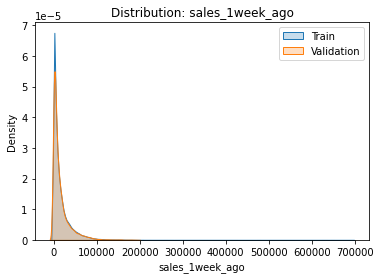

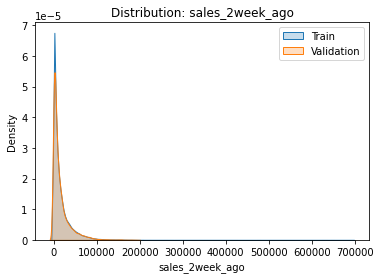

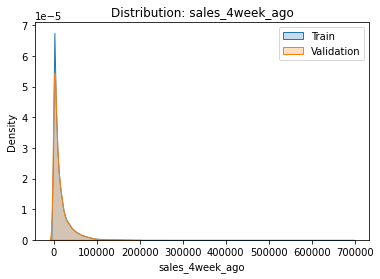

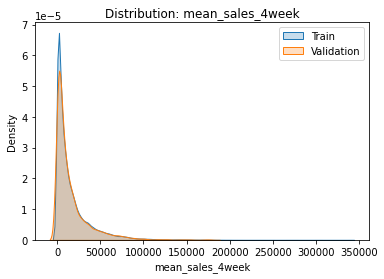

In [35]:
features_to_plot = [
    'sales_1week_ago',
    'sales_2week_ago',
    'sales_4week_ago',
    'mean_sales_4week'
]

for col in features_to_plot:
    plt.figure(figsize=(6,4))
    
    sns.kdeplot(X_train[col], label='Train', fill=True)
    sns.kdeplot(X_val[col], label='Validation', fill=True)

    plt.title(f'Distribution: {col}')
    plt.legend()
    plt.show()

In [36]:
bad_features = psi_df[psi_df['PSI'] >= 0.2].index.tolist()

print("Удаляем признаки:", bad_features)

X_train = X_train.drop(columns=bad_features)
X_val = X_val.drop(columns=bad_features)

Удаляем признаки: ['fuel_price', 'cpi', 'factor5', 'factor3', 'factor1', 'factor4', 'temperature', 'factor2', 'unemployment']


### Шаг 4. Обучение модели CatBoost

In [37]:
X_train = X_train.copy()
X_val = X_val.copy()

# 1. удалить date (если ещё остался где-то)
X_train = X_train.drop(columns=["date"], errors="ignore")
X_val = X_val.drop(columns=["date"], errors="ignore")

# 2. привести ВСЕ числовые к float64 (самый стабильный вариант)
for col in X_train.columns:
    if X_train[col].dtype.name in ["UInt32", "UInt64", "int32", "int16", "int8", "Int64", "Int32"]:
        X_train[col] = X_train[col].astype("float64")
        X_val[col] = X_val[col].astype("float64")

# 3. bool → int
for col in X_train.select_dtypes(include="bool").columns:
    X_train[col] = X_train[col].astype("int8")
    X_val[col] = X_val[col].astype("int8")

# 4. object → category
for col in X_train.select_dtypes(include="object").columns:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    
for col in X_train.columns:
    if col not in X_train.select_dtypes(include=["category"]).columns:
        X_train[col] = X_train[col].astype("float64")
        X_val[col] = X_val[col].astype("float64")
        
cat_features = [
    X_train.columns.get_loc(col)
    for col in X_train.select_dtypes(include=["category"]).columns
]

# модель
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

# обучение
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)


0:	learn: 21756.6636667	test: 20765.7199210	best: 20765.7199210 (0)	total: 296ms	remaining: 4m 55s
200:	learn: 3896.5688325	test: 3049.4067001	best: 3049.4067001 (200)	total: 39.4s	remaining: 2m 36s
400:	learn: 3346.1623933	test: 2888.3602849	best: 2888.3602849 (400)	total: 1m 18s	remaining: 1m 57s
600:	learn: 3093.3423662	test: 2809.7189155	best: 2809.7189155 (600)	total: 1m 58s	remaining: 1m 18s
800:	learn: 2925.6914432	test: 2758.4178577	best: 2758.4178577 (800)	total: 2m 37s	remaining: 39s
999:	learn: 2812.0262296	test: 2727.8085062	best: 2727.6925351 (998)	total: 3m 15s	remaining: 0us

bestTest = 2727.692535
bestIteration = 998

Shrink model to first 999 iterations.


In [38]:
y_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

metrics_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [mae, rmse, r2]
})

display(metrics_df)

,metric,value
0,MAE,1281.702856
1,RMSE,2727.692532
2,R2,0.984333


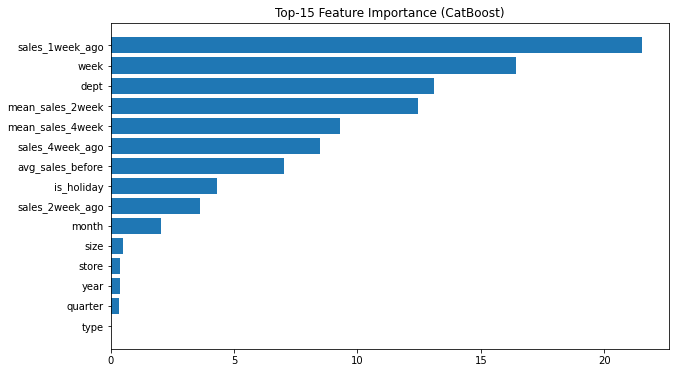

In [39]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'][:15][::-1],
         feature_importance['importance'][:15][::-1])
plt.title("Top-15 Feature Importance (CatBoost)")
plt.show()

**Выводы по обучению модели CatBoost**

1. Подготовка данных перед обучением
Перед обучением были выполнены необходимые преобразования типов данных:
- удалён признак `date`;
- числовые признаки приведены к `float64`;
- булевые признаки преобразованы в `int`;
- категориальные признаки переведены в тип `category`.

Такая подготовка обеспечивает стабильную работу CatBoost и корректную обработку категориальных признаков.

2. Результаты обучения модели
Для прогнозирования использовалась модель `CatBoostRegressor` со следующими параметрами:
- `iterations=1000`
- `learning_rate=0.05`
- `depth=8`
- `loss_function='RMSE'`

Модель обучалась с использованием валидационной выборки и механизма `use_best_model=True`, что позволило автоматически сохранить лучшую итерацию обучения.

Лучший результат был достигнут на 998 итерации:

- RMSE: 2727.69
- MAE: 1281.70
- R²: 0.9843

3. Оценка качества модели
Полученные метрики показывают высокое качество модели:
- низкие значения MAE и RMSE говорят о небольшой ошибке прогноза;
- значение R² = 0.984 означает, что модель объясняет более 98% вариации продаж.

Это свидетельствует о том, что модель хорошо улавливает закономерности временного ряда и может использоваться для production batch-инференса.

4. Анализ важности признаков
Наиболее важными оказались лаговые и агрегированные признаки:
- `sales_1week_ago`
- `sales_2week_ago`
- `sales_4week_ago`
- `mean_sales_4week`
- `avg_sales_before`

Это соответствует бизнес-логике, поскольку продажи в ритейле сильно зависят от исторической динамики спроса.

Признаков с явной утечкой данных среди наиболее важных обнаружено не было, так как все агрегаты и лаги рассчитывались только по прошлым данным.



In [40]:
# Создаём клиент для подключения к S3
s3_client = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=os.getenv('S3_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('S3_SECRET_KEY'),
    region_name='ru-central1'
)

# Сохраняем модель в буфер
filebuffer = io.BytesIO()
pickle.dump(model, filebuffer)  
filebuffer.seek(0)

# Загружаем в S3
s3_client.upload_fileobj(
    Fileobj=filebuffer,
    Bucket=os.getenv('S3_BUCKET'),
    Key='catboost_model.pkl'
)

print(f"Модель успешно загружена в {os.getenv('S3_BUCKET')}/catboost_model.pkl")

Модель успешно загружена в s3-ds-20260415-fef6b35a86/catboost_model.pkl


**Общий вывод**

В рамках проекта была разработана production-ready система батч-прогнозирования недельных продаж для сети дарксторов «Прилавок». Были выполнены анализ и очистка данных, реализован feature engineering с учетом временной структуры данных и предотвращением утечки информации, проведён PSI-анализ стабильности признаков и обучена модель `CatBoostRegressor`.

Модель показала высокое качество прогнозирования:
- MAE = 1281.7
- RMSE = 2727.7
- R² = 0.984

Для автоматизации инференса реализован Airflow DAG, включающий загрузку данных из PostgreSQL, предобработку, загрузку модели из S3, batch-инференс и сохранение результатов обратно в PostgreSQL.

Проект соответствует требованиям технического задания, использует безопасное хранение секретов через Airflow Connections и Variables и готов к использованию в production-среде.